#####  TWITTER SENTIMENT ANALYSIS CLASSIFIER FOR APPLE AND GOOGLE PRODUCTS

Author: Jackline Mwau

Author: Jackline Mwau

1. BUSINESS UNDERSTANDING

1.1. Project Overview

This project will build a Natural Language Processing (NPL) model that classifies twitter sentiments that are related to Google and Apple products. The aim of the sentiment analysis is to comprehend the public opinion and emotions towards the particular brands to enable companies to monitor brand perception, customer satisfaction and identify potential issues. The project will build a proof-of-concept model that starts with a simple binary classification (Positive & Negative) and extent to a more realistic multiclass setting

1.2. Problem Statement

Thousands of consumers give their opinions on Apple and Google products through social media platforms such as Twitter. Many companies monitor these opinions to understand on their brand perception in the market for better decision-making and improvements. Manual monitoring of online consumer opinions is difficult hence; most firms have established automated methods for identifying customer sentiments towards a brand. Natural Language Processing (NPL) is one of the solutions that automatically classify tweets related to Apple and Google products based on sentiments.

1.3. Stakeholders

The main stakeholders include:

- Marketing Team – Identifying the public opinion towards the product for better formulation of market campaigns.

- Customer Excellence Team- Essential in identify customer complaints and recommending strategies for improvement.

- Product and brand managers- Identifying the strengths and weakness of the brand and reputation.

- Company Executives- Vital in supporting strategic decision-making.


1.4. Business Questions:
- Can tweets about Apple and Google products be automatically classified as positive, negative or neutral for better understanding of customer sentiment?

- What is the overall sentiment toward Apple and Google products?

- Which products generate the most positive and negative reactions?

- What words are commonly associated with positive and negative sentiment?

- How accurately can machine learning predict tweet sentiment?


1.5. Project Objective

## General Objective

- The project’s main objective is developing a NPL sentiment analysis model with a capability of automatically classifies tweet related to Apple and Google products into Positive, Negative and neutral categories. 

- Analyzing the consumer opinions on twitter will assist stakeholders to understand public perception of the products, monitor brand and customer concerns.

## Specific Objectives:
- Analyze Twitter data on Apple and Google products to enable understand customer opinions and patterns.

- Preprocess and transform text data to suitable machine learning.

- Building and comparing multiple classification models for sentiment prediction.

- Evaluation of model performance by use of Accuracy, Precision, Recall and F1 scores.

- Identification of key words linked to the sentiments.

- Provide solution and actionable insights based on the feedback. The model is considered successful if it correctly classifies sentiments and actionable insights into the perceptions of Apple and Google products.


#### Success Metrics

Technical Metric: Achieve a Macro $F_1$-score $\ge$ 0.75. A macro-averaged evaluation ensures our pipeline performs accurately on minority classes (negative sentiment), which prevents the model from defaulting heavily to the majority class.

Business Metric: Integrate model explainability parameters to decode specific feature weights, allowing product engineering groups to extract actionable item lists from flagged spikes in negative customer conversations.


2. DATA UNDERSTANDING

### 2.1. Data Source

The data was sourced from CrowdFlower via data.world. The dataset contains text data which are tweets about Apple and Google products and labels which are sentiments (positives, negatives and neutral).


### 2.2. Key Variables

The dataset has 3 columns with three variables namely;

a)Tweet_text- describes the original tweet content

b)Sentiment – provides the sentiment label (positive, negative, neutral)

c)Product - Products mentioned are Apple or Google


### 2.3.Target Variable

The target variable is sentiment. It will help in identifying the distribution of sentiment classes and potential imbalance between classes.

•	Distribution of sentiment classes 

•	Examples of tweets in each category 

•	Potential imbalance between classes 

This step is important because imbalanced data can bias a model toward predicting the majority class


### Target Variable Distribution

| Sentiment | Count | Percentage (%) |
|-----------|-------|----------------|
| No emotion toward brand or product | 5389 | 59.3 |
| Positive emotion | 2978 | 32.8 |
| Negative emotion | 570 | 6.3 |
| I can't tell | 156 | 1.7 |
| **Total** | **9093** | **100.0** |

#### Key Observation
The dataset is highly imbalanced. The 'No emotion toward brand or product' is the majority class accounting for 60% of all the sentiments, while negative sentiment represents only about 6% of the data.

Because of this imbalance, accuracy would be a misleading performance metric. A model predicting only "No emotion toward brand or product" would achieve high accuracy but fail to detect meaningful positive or negative feedback. Therefore, F1-score (macro or weighted) is selected as the primary evaluation metric, as it balances precision and recall across all classes, especially the minority classes

### 3. DATA PREPARATION AND CLEANING
#### Text Preprocessing
In this stage, we transform the tweet dataset into a suitable format for machine learning through a structured preprocessing workflow. The text preprocessing workflow include:

- Convestion of text to lowercase.

- Removal of URLs

- Removal of twitter handles

- Removal of punctuation and special characters

- Removal of stopwords 

- Lemmatization 

#### Data Cleaning Process

The dataset will then be cleaned by removing missing values to enhance reliability, elimination of stop words, removal of tweets labelled *“I can’t tell”* and simplifying the **target_brand** field into two main groups(Apple and Google)

#### Results
These steps are vital in reducing irrelevant information, standardizing the text, and improving the effectiveness of the sentiment classification model.
The complete preprocessed tweet is converted into a clean and standardized text for vectorization using TF-IDF thus enhancing computational efficienct and performance of the sentiment model.


### Import the Required Libraries

In [3]:
#importing libraries
# Core data handling
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Plotting aesthetics
sns.set_theme(style="whitegrid")
%matplotlib inline

# NLP preprocessing
import re
import string

# NLTK tools
import nltk
nltk.download('stopwords')
nltk.download('punkt')
nltk.download('wordnet')

from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\jac\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\jac\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\jac\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


### 3.1. Load Dataset & Inspect Data

In [4]:
# Load the dataset
df = pd.read_csv('judge-1377884607_tweet_product_company.csv', encoding='unicode_escape')

In [5]:
# Display the first few rows of the dataset
df.head()

,tweet_text,emotion_in_tweet_is_directed_at,is_there_an_emotion_directed_at_a_brand_or_product
0,.@wesley83 I have a 3G iPhone. After 3 hrs twe...,iPhone,Negative emotion
1,@jessedee Know about @fludapp ? Awesome iPad/i...,iPad or iPhone App,Positive emotion
2,@swonderlin Can not wait for #iPad 2 also. The...,iPad,Positive emotion
3,@sxsw I hope this year's festival isn't as cra...,iPad or iPhone App,Negative emotion
4,@sxtxstate great stuff on Fri #SXSW: Marissa M...,Google,Positive emotion


In [6]:
# Check the dimensions of the dataset
df.shape

(9093, 3)

The dataset contains 9093 rows and 3 columns

In [7]:
# Rename columns for cleaner coding access
df.rename(columns={
    'tweet_text': 'tweet',
    'emotion_in_tweet_is_directed_at': 'target_brand',
    'is_there_an_emotion_directed_at_a_brand_or_product': 'sentiment'
}, inplace=True)

### 3.2. Data Understanding

In [8]:
# Explore the dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9093 entries, 0 to 9092
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   tweet         9092 non-null   object
 1   target_brand  3291 non-null   object
 2   sentiment     9093 non-null   object
dtypes: object(3)
memory usage: 213.2+ KB


The dataset contains tweets discussing Apple and Google products.

The target variable is sentiment.

The numerical features provide information about tweet length and complexity.

The tweet column contains the raw tweet content.

In [9]:
# Check for missing values
df.isnull().sum()

tweet              1
target_brand    5802
sentiment          0
dtype: int64

The target variable 'sentiment' has no missing values while the tweet text has 1 null row which we will drop. 

In [10]:
# Check for duplicates
df.duplicated().sum()

22

In [11]:
# Check the distribution of sentiments
df['sentiment'].value_counts()

No emotion toward brand or product    5389
Positive emotion                      2978
Negative emotion                       570
I can't tell                           156
Name: sentiment, dtype: int64

#### Visualize the distribution of sentiments

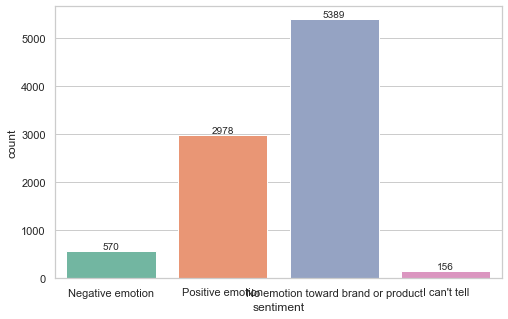

In [12]:
plt.figure(figsize=(8, 5))

ax = sns.countplot(
    data=df,
    x='sentiment',
    
    palette='Set2',
    
)

# Add value labels on top of bars
for p in ax.patches:
    ax.annotate(
        f'{int(p.get_height())}',
        (p.get_x() + p.get_width() / 2, p.get_height()),
        ha='center',
        va='bottom',
        fontsize=10
    )

### Observations

The dataset is imbalanced with the 'No emotion toward brand or product' apprearing more frequent. This can lead to biases hence Macro F1-Score and stratified sampling can be used to improve reliability of the matrices. Neutral tweets account for the majority of observations, indicating that most conversations are informational rather than emotional in nature.

Positive sentiment is the second most frequent category, suggesting that a substantial number of users expressed favorable opinions, excitement, or satisfaction with the products and services featured during the event.

Negative sentiment constitutes the smallest share of tweets, indicating that direct complaints, criticism, and negative user experiences are comparatively uncommon. However, despite their low frequency, these tweets may contain valuable insights into customer concerns and potential brand risks.

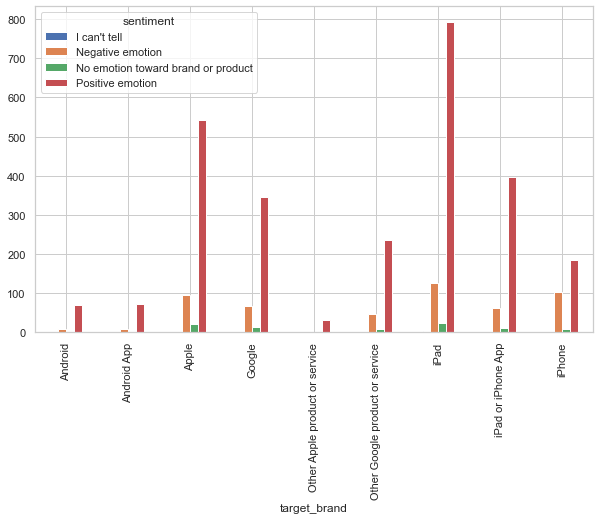

In [13]:
# Check the distribution of target brands and visualize
df['target_brand'].value_counts()

# visualize the distributions
df.groupby(['target_brand', 'sentiment']).size().unstack().plot(
    kind='bar',
    figsize=(10,6)
)
plt.show()

#### Observations
- Sentiment distribution differs by brand, suggesting varying levels of customer satisfaction and engagement
- Positive tweets generally outnumber negative tweets, indicating overall favorable brand perception.
- Negative sentiment is relatively rare but may highlight important customer concerns and product issues.


### 3.3 Cleaning the dataset

Tweets often contain:URLs, mentions, hashtags, punctuation which add noise to the model and reduce its performance.


In [14]:
# Drop rows with missing tweets
df = df.dropna(subset=['tweet'])

In [15]:
# Check missing values again
df.isnull().sum()

tweet              0
target_brand    5801
sentiment          0
dtype: int64

In [16]:
# Remove duplicates and check whether they are removed
df = df.drop_duplicates()
df.duplicated().sum()

0

In [17]:
#  Fill missing values in 'target_brand' with 'unknown'
df['target_brand'] = df['target_brand'].fillna('unknown')

In [18]:
# Remove the I cant tell sentiment category
df = df[df['sentiment'] != "I can't tell"].copy()

In [19]:
# Check the distribution of sentiments again after removing "I can't tell"
print(df['sentiment'].value_counts())

print("\nPercentages:")
print(df['sentiment'].value_counts(normalize=True) * 100)

No emotion toward brand or product    5375
Positive emotion                      2970
Negative emotion                       569
Name: sentiment, dtype: int64

Percentages:
No emotion toward brand or product    60.298407
Positive emotion                      33.318376
Negative emotion                       6.383217
Name: sentiment, dtype: float64


In [20]:
# Define brand mapping using sets for faster lookup
apple_brands = {
    'ipad',
    'apple',
    'iphone',
    'ipad or iphone app',
    'other apple product or service'
}

google_brands = {
    'google',
    'other google product or service',
    'android',
    'android app'
}

def merge_brands(brand):
    if pd.isna(brand):
        return None
    
    brand = brand.strip().lower()
    
    if brand in apple_brands:
        return 'apple'
    elif brand in google_brands:
        return 'google'
    else:
        return 'other'

df['target_brand'] = df['target_brand'].apply(merge_brands)

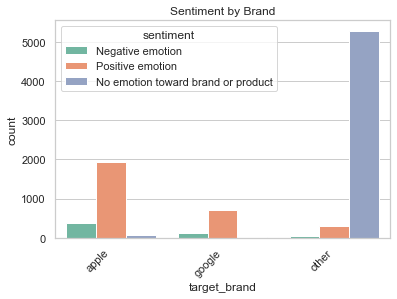

In [21]:
ax = sns.countplot(
    data=df,
    x='target_brand',
    hue='sentiment',
    palette='Set2'
)


plt.xticks(rotation=45, ha='right')
plt.title("Sentiment by Brand")
plt.show()

### 3.4 Text preprocessing to clean the tweets

In [22]:
# Text preprocessing to clean the tweets

from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS
stop_words = set(ENGLISH_STOP_WORDS)
custom_stopwords = {'sxsw', 'amp', 'rt', 'just', 'new', 'today', 'via'}

# Emoji pattern
emoji_pattern = re.compile(
    "["
    "\U0001F600-\U0001F64F"
    "\U0001F300-\U0001F5FF"
    "\U0001F680-\U0001F6FF"
    "\U0001F1E0-\U0001F1FF"
    "\U00002700-\U000027BF"
    "\U000024C2-\U0001F251"
    "]+",
    flags=re.UNICODE
)

def clean_tweet(text):
    text = str(text).lower()

    # Remove URLs and placeholders
    text = re.sub(r'http\S+|\{link\}', '', text)

    # Remove HTML artifacts
    text = re.sub(r'&amp;', '', text)

    # Remove mentions and hashtags symbol
    text = re.sub(r'@\w+', '', text)
    text = re.sub(r'#', '', text)

    # Remove emojis
    text = emoji_pattern.sub('', text)

    # Remove punctuation / non-letters
    text = re.sub(r'[^a-z\s]', '', text)

    # Tokenize and filter words
    words = text.split()
    words = [
        w for w in words
        if w not in stop_words
        and w not in custom_stopwords
        and len(w) > 2
    ]

    return ' '.join(words)

df['clean_tweet'] = df['tweet'].apply(clean_tweet)

In [23]:
# Check the cleaned tweets and the frequency of words again
from collections import Counter

all_words = ' '.join(df['clean_tweet']).split()
word_counts = Counter(all_words)

freq_df = pd.DataFrame(word_counts.most_common(10), columns=['Word', 'Frequency'])
freq_df

,Word,Frequency
0,ipad,2832
1,google,2280
2,apple,2109
3,iphone,1485
4,store,1444
5,austin,936
6,app,807
7,launch,637
8,social,625
9,circles,605


In [24]:
# Convert tweets to string and apply preprocessing
df['clean_tweet'] = df['tweet'].astype(str).apply(clean_tweet)

#### 4. EXPLORATORY DATA ANALYSIS (EDA)

### 4.1. Feature engineering for exploratory insights

In [25]:
df['tweet_length'] = df['clean_tweet'].apply(len)
df['word_count'] = df['clean_tweet'].apply(lambda x: len(x.split()))
print(df['tweet_length'] )
print(df['word_count'])

0        64
1        77
2        14
3        48
4        95
       ... 
9088      4
9089     80
9090    108
9091     82
9092     27
Name: tweet_length, Length: 8914, dtype: int64
0        9
1       11
2        3
3        8
4       13
        ..
9088     1
9089    11
9090    13
9091    11
9092     4
Name: word_count, Length: 8914, dtype: int64


### 4.2. Visualization of the Target variable distribution 

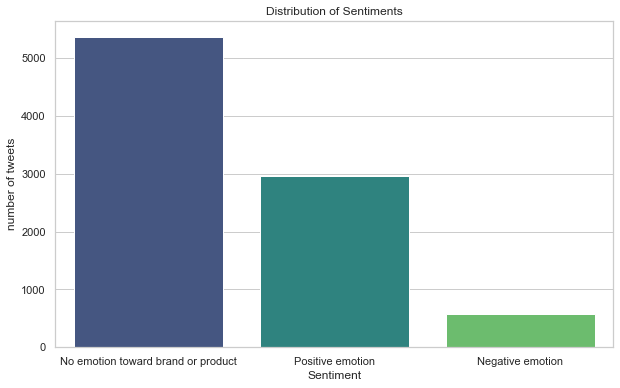

In [26]:
# plotting the distribution of tweet lengths
plt.figure(figsize=(10, 6)) 
sns.countplot(data=df, x='sentiment', order=df['sentiment'].value_counts().index, palette='viridis')
plt.title('Distribution of Sentiments')
plt.xlabel('Sentiment')
plt.ylabel('number of tweets')
plt.show()

The distribution of sentiments show that most tweet sentiments were neutral while a medium number of tweets were of positive emotion sentiments.

### 4.3. Visualizing Text Length Distribution by Class

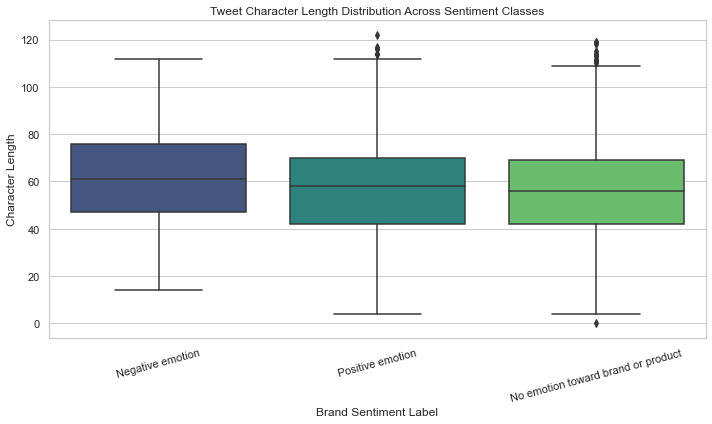

In [27]:
# plotting the distribution of tweet lengths
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='sentiment', y='tweet_length', palette='viridis')
plt.title('Tweet Character Length Distribution Across Sentiment Classes')
plt.xlabel('Brand Sentiment Label')
plt.ylabel('Character Length')
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

### 4.4. Product Mention Distributions

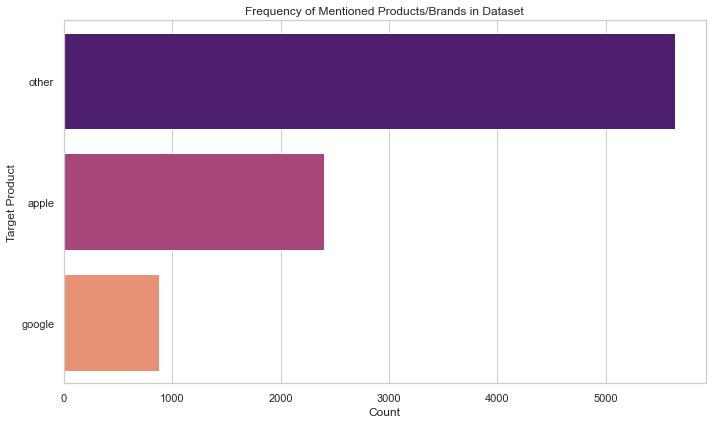

In [28]:
plt.figure(figsize=(10, 6))
sns.countplot(data=df, y='target_brand', 
              order=df['target_brand'].value_counts().index, palette='magma')
plt.title('Frequency of Mentioned Products/Brands in Dataset')
plt.xlabel('Count')
plt.ylabel('Target Product')
plt.tight_layout()
plt.show()

### 4.5. Sentiment Distribution among different brand/products

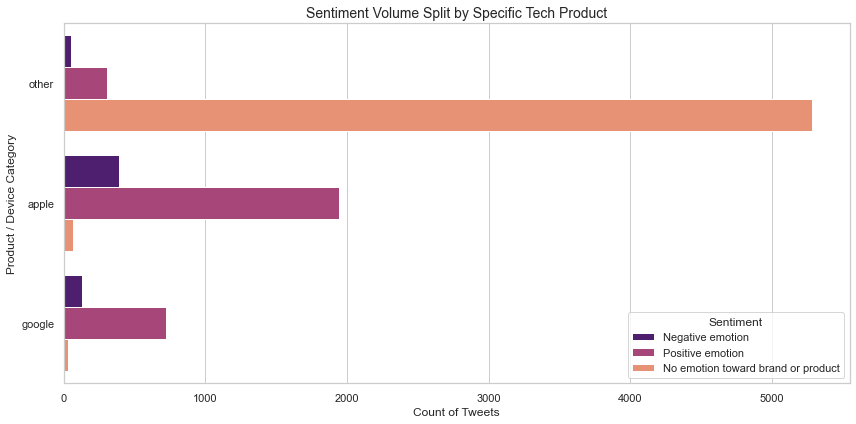

In [29]:
# Filter out rows where product metadata is missing
product_df = df.dropna(subset=['target_brand'])

plt.figure(figsize=(12, 6))
sns.countplot(data=product_df, y='target_brand', hue='sentiment', 
              order=product_df['target_brand'].value_counts().index, palette='magma')
plt.title('Sentiment Volume Split by Specific Tech Product', fontsize=14)
plt.xlabel('Count of Tweets')
plt.ylabel('Product / Device Category')
plt.legend(title='Sentiment', loc='lower right')
plt.tight_layout()
plt.show()

The data as seen in the different graphs above is imbalanced as more 50% of the sentiments are neutral (No emotion toward brand or product). This imbalance results to misleading model performance metrices such as accurecy hence making it unreliable in business decisions.

**Stratified Folds** during modeling and reliance on the **Macro F1-Score** and **Negative Recall** for validation can assist improve the model performance.

In [30]:
# Check the cleaned tweets and the frequency of words again
from collections import Counter

all_words = ' '.join(df['clean_tweet']).split()
word_counts = Counter(all_words)

freq_df = pd.DataFrame(word_counts.most_common(10), columns=['Word', 'Frequency'])
freq_df

,Word,Frequency
0,ipad,2832
1,google,2280
2,apple,2109
3,iphone,1485
4,store,1444
5,austin,936
6,app,807
7,launch,637
8,social,625
9,circles,605


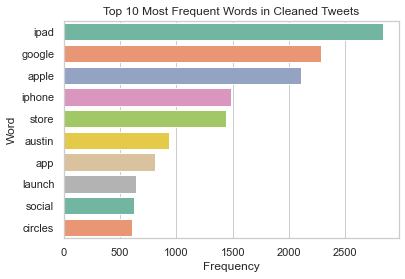

In [31]:
# Visualize the top 10 frequently used words
x = sns.barplot(
    data=freq_df,
    x='Frequency',
    y='Word',
    palette='Set2',
   
)

plt.title('Top 10 Most Frequent Words in Cleaned Tweets')
plt.xlabel('Frequency')
plt.ylabel('Word')
plt.show()

# observation

The most frequent words highlight the main themes in the cleaned tweets, showing the key topics users are talking about. This helps in understanding common discussion patterns and overall sentiment context in the dataset.

### 5. BUILDING THE MODEL AND EVALUATION

### 5.1. Model 1: Logistic Regression

We start with baseline model due to its good perfomance on high-dimensional sparse text data and interpretable outputs.

### 5.1.1. Binary Classification 

In [32]:
# Start with only simple binary classification: Positive vs Negative
binary_df = df[df['sentiment'] != 'No emotion toward brand or product'].copy()

# Encode the target variable for binary classification
binary_df['sentiment'] = binary_df['sentiment'].map({
    'Negative emotion': 0,
    'Positive emotion': 1
})

In [33]:
# Feature extraction using TF-IDF
from sklearn.feature_extraction.text import TfidfVectorizer
tfidf = TfidfVectorizer(max_features=5000, ngram_range=(1, 2))

X1 = tfidf.fit_transform(binary_df['clean_tweet'])
y1 = binary_df['sentiment']

The model cannot directly read text hence TF-IDF assists to capture important words, words frequency and importance across documents. 

Using (1,2) includes single words and two-word phrases.


In [34]:
# split the data into training and testing sets with stratification to maintain class balance
# 80% training, 20% testing, random state for reproducibility, stratify to maintain class distribution

X_train_1, X_test_1, y_train_1, y_test_1 = train_test_split(X1, y1, test_size=0.2, random_state=42, stratify=y1)


In [35]:
# create and train a logistic regression model
from sklearn.linear_model import LogisticRegression


lr_b = LogisticRegression(max_iter=1000)

lr_b.fit(X_train_1, y_train_1)


LogisticRegression(max_iter=1000)

In [36]:
# predict on the test set
y_pred = lr_b.predict(X_test_1)

In [37]:
# evaluate the model performance
print("Classification Report:\n", classification_report(y_test_1, y_pred))
print("Accuracy Score:", accuracy_score(y_test_1, y_pred))
print("F1 Score:", classification_report(y_test_1, y_pred, output_dict=True)['weighted avg']['f1-score'])


Classification Report:
               precision    recall  f1-score   support

           0       0.79      0.10      0.17       114
           1       0.85      0.99      0.92       594

    accuracy                           0.85       708
   macro avg       0.82      0.55      0.54       708
weighted avg       0.84      0.85      0.80       708

Accuracy Score: 0.8502824858757062
F1 Score: 0.7976110972207602


The linear regression model using the binary classication (Negative and positive emotions) achueved an accurecy score of 85% and F1 score of 79%. However, the recall for the negative emotions was 0.10 compared to 0.99 of the majority class(positive emotions)
 This shows that the model was biased toward the majority class.


In [38]:
# cross validation for more robust performance estimation
from sklearn.model_selection import cross_val_score
cv_scores = cross_val_score(lr_b, X1, y1, cv=5, scoring='f1_weighted')
print("Cross-Validation F1 Scores:", cv_scores)
print("Mean CV F1 Score:", cv_scores.mean())

Cross-Validation F1 Scores: [0.79137344 0.79137344 0.78743709 0.79441563 0.77969498]
Mean CV F1 Score: 0.7888589168854045


After applying class weighting to handle imbalance, the model became more balanced. Although this slightly reduced precision, it improved the ability to detect negative sentiments, increasing recall. Cross-validation provides a more reliable estimate than a single train-test split


### 5.1.2. Logistic Regression with Multiclass Classification

In this case, we are improving the model further by taking into consideration all the sentiments.

In [39]:
# Define features and target variable
X = df[['clean_tweet', 'target_brand']]
y = df['sentiment']  

In [40]:
# Split the data into training and testing sets with stratification to maintain class distribution, a test size of 20%, 
# and a random state for reproducibility
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [41]:
# Define preprocessing steps for different feature types
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import OneHotEncoder

preprocessor = ColumnTransformer([
    ('text', TfidfVectorizer(max_features=5000, stop_words='english'), 'clean_tweet'),
    ('brand', OneHotEncoder(handle_unknown='ignore'), ['target_brand'])
])

In [42]:
# Create a machine learning pipeline that first preprocesses data then trains a classifier
from sklearn.pipeline import Pipeline
model_1 = Pipeline(steps=[
    ('preprocess', preprocessor),
    # Logistic Regression model for classification
    ('clf', LogisticRegression(max_iter=1000))
])


In [43]:
# Train the model using training data
model_1.fit(X_train, y_train)

Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('text',
                                                  TfidfVectorizer(max_features=5000,
                                                                  stop_words='english'),
                                                  'clean_tweet'),
                                                 ('brand',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['target_brand'])])),
                ('clf', LogisticRegression(max_iter=1000))])

In [44]:
# Make predictions on the test set using the trained model
y_pred_1 = model_1.predict(X_test)

# Print overall accuracy of the model
print("Accuracy:", accuracy_score(y_test, y_pred_1))

# Display detailed performance metrics (precision, recall, f1-score)
# for each class in the target variable
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_1))

Accuracy: 0.9024116657319126

Classification Report:

                                    precision    recall  f1-score   support

                  Negative emotion       0.76      0.17      0.27       114
No emotion toward brand or product       0.94      0.98      0.96      1075
                  Positive emotion       0.84      0.90      0.87       594

                          accuracy                           0.90      1783
                         macro avg       0.85      0.68      0.70      1783
                      weighted avg       0.90      0.90      0.89      1783



# observation

Although the model achieved a high overall accuracy of 90%, its performance was uneven across the different sentiment classes. It performed well in identifying the majority class (“No emotion toward brand or product”) at 94% and the positive class, but struggled with the negative class, which had very low recall (0.17).

This means the model often failed to correctly detect negative sentiments and tended to favor the more common classes. The results suggest that class imbalance influenced the model’s predictions.

In [45]:
# Class imbalance handling with class_weight='balanced'
model = Pipeline(steps=[
    ('preprocess', preprocessor),
    ('clf', LogisticRegression(max_iter=1000, class_weight='balanced'))
])

In [46]:
# Create a new pipeline with class imbalance handling using class weights
model = Pipeline(steps=[
    ('preprocess', preprocessor),
    
    # Logistic Regression model with balanced class weights
    # This helps the model give more importance to minority classes
    ('clf', LogisticRegression(max_iter=1000, class_weight='balanced'))
])

# Train the model on the training data
model.fit(X_train, y_train)

Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('text',
                                                  TfidfVectorizer(max_features=5000,
                                                                  stop_words='english'),
                                                  'clean_tweet'),
                                                 ('brand',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['target_brand'])])),
                ('clf',
                 LogisticRegression(class_weight='balanced', max_iter=1000))])

In [47]:
# Generate predictions on the test dataset using the trained balanced model
y_pred_2 = model.predict(X_test)

# Print overall model accuracy
print("Accuracy:", accuracy_score(y_test, y_pred_2))

# Display detailed evaluation metrics:
# precision, recall, and f1-score for each class
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_2))

Accuracy: 0.8968031407739765

Classification Report:

                                    precision    recall  f1-score   support

                  Negative emotion       0.49      0.60      0.54       114
No emotion toward brand or product       0.94      0.98      0.96      1075
                  Positive emotion       0.91      0.80      0.86       594

                          accuracy                           0.90      1783
                         macro avg       0.78      0.79      0.78      1783
                      weighted avg       0.90      0.90      0.90      1783



Applying the class weighting reduces the model biasness making the model more balance. The precision score for the minority class(negative sentiments) gradually increases.

Overall, the updated model is more reliable for real-world use cases where identifying negative feedback is important.


### 5.2. Model 2. Multinomial Naive Bayes 

This model is widely used in task classification tasks due to its simplicity, speed to train, and works well with word-frequency based features.

In [48]:
# Train multinomial naive bayes classifier

from sklearn.pipeline import Pipeline
from sklearn.naive_bayes import MultinomialNB

multi_nb = Pipeline(steps=[
    ('preprocess', preprocessor),
    ('clf', MultinomialNB())
])

In [49]:
# Fit the model on the training data
multi_nb.fit(X_train, y_train)

Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('text',
                                                  TfidfVectorizer(max_features=5000,
                                                                  stop_words='english'),
                                                  'clean_tweet'),
                                                 ('brand',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['target_brand'])])),
                ('clf', MultinomialNB())])

In [50]:
# Predict with the Multinomial Naive Bayes model
y_pred_nb = multi_nb.predict(X_test)

In [51]:
# Calculate and display the overall accuracy of the model
print("Accuracy:", accuracy_score(y_test, y_pred_nb))

# Generate a classification report showing precision,
# recall, and F1-score for each sentiment class
print(classification_report(y_test, y_pred_nb))

# Display the confusion matrix to compare actual
# versus predicted class labels
print(confusion_matrix(y_test, y_pred_nb))

Accuracy: 0.8962422882781829
                                    precision    recall  f1-score   support

                  Negative emotion       1.00      0.03      0.05       114
No emotion toward brand or product       0.94      0.98      0.96      1075
                  Positive emotion       0.82      0.91      0.86       594

                          accuracy                           0.90      1783
                         macro avg       0.92      0.64      0.62      1783
                      weighted avg       0.90      0.90      0.87      1783

[[   3   10  101]
 [   0 1057   18]
 [   0   56  538]]


The model has a low capability of identifying negative sentiments with a recall of 3%. Although it achieved a precision score of 1, this does not indicate strong performance. This implies that the model only predited few negative but correct tweets.

The low recall score of 3% also shows that the model was unable to identify the most or almost all the negative tweets. The model either classified the negative tweets as positve or neutral.

From the above trend, the model seems to be highly biased towards the majority classes which makes it unable to study the patterns linked with the negative comments.


### 5.3. Model 3. LinearSVC

We have also developed a linear SVM model due to it's  effectiveness for text data with many features. It often achieves high accuracy in classification tasks involving high-dimensional feature spaces.

In [52]:
# Linear SVC model with class weights to handle class imbalance
from sklearn.svm import LinearSVC
model_Ls = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', LinearSVC(class_weight='balanced'))
])


In [53]:
#fitting the model

model_Ls.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('text',
                                                  TfidfVectorizer(max_features=5000,
                                                                  stop_words='english'),
                                                  'clean_tweet'),
                                                 ('brand',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['target_brand'])])),
                ('classifier', LinearSVC(class_weight='balanced'))])

In [54]:
# Generate predictions using the trained Support Vector Classifier (SVC)
y_pred_2 = model_Ls.predict(X_test)

# Display the overall accuracy of the model
print("Accuracy:", accuracy_score(y_test, y_pred_2))

# Display precision, recall, and F1-score for each sentiment class
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_2))

Accuracy: 0.8984856982613573

Classification Report:

                                    precision    recall  f1-score   support

                  Negative emotion       0.54      0.45      0.49       114
No emotion toward brand or product       0.94      0.97      0.96      1075
                  Positive emotion       0.88      0.85      0.86       594

                          accuracy                           0.90      1783
                         macro avg       0.78      0.76      0.77      1783
                      weighted avg       0.89      0.90      0.90      1783



The SVC model achieved an accurecy score of 89%. However, the balance across the sentiments improved especially for the minoruty class (negative).

The precision and recall scores for the positive and neutral classes also improved hence suggesting better performance of the model.

SVC provided a more balanced classification performance, making it more effective at identifying negative sentiment while still maintaining average overall accuracy

### 5.3.1. Hyperparameter Tuning of LinearSVC

In [55]:
# Define the pipeline: preprocessing + classifier
from sklearn.model_selection import GridSearchCV

pipe = Pipeline([
    ('preprocessor', preprocessor),
    ('clf', LinearSVC(class_weight='balanced'))
])

# Define hyperparameter search space
param_grid = {
    'preprocessor__text__max_features': [5000, 10000],
    'preprocessor__text__ngram_range': [(1,1), (1,2)],
    'classifier__C': [0.1, 1, 10]
}


# GridSearch with cross-validation
grid = GridSearchCV(
    estimator=model_Ls,
    param_grid=param_grid,
    cv=3,
    scoring='f1_macro',
    n_jobs=-1,
    verbose=2
)


# Train model and search for best parameters
grid.fit(X_train, y_train)

Fitting 3 folds for each of 12 candidates, totalling 36 fits


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 2 concurrent workers.
[Parallel(n_jobs=-1)]: Done  36 out of  36 | elapsed:   38.5s finished


GridSearchCV(cv=3,
             estimator=Pipeline(steps=[('preprocessor',
                                        ColumnTransformer(transformers=[('text',
                                                                         TfidfVectorizer(max_features=5000,
                                                                                         stop_words='english'),
                                                                         'clean_tweet'),
                                                                        ('brand',
                                                                         OneHotEncoder(handle_unknown='ignore'),
                                                                         ['target_brand'])])),
                                       ('classifier',
                                        LinearSVC(class_weight='balanced'))]),
             n_jobs=-1,
             param_grid={'classifier__C': [0.1, 1, 10],
                         'prepro

We performed the hyperparameter tuning on the LinearSVC model in order to improve its classication performance. 

Cross-validation assisted in model regularization and the use of macro F1-score helps ensure that all the sentiment classes, both majority and minority are taken into consideration during model selection.


In [56]:
# Extract the best-performing model from GridSearchCV
best_model = grid.best_estimator_

# Display the best hyperparameters found during tuning
print("Best Parameters:")
print(grid.best_params_)

# Make predictions using the best model
y_pred_3 = best_model.predict(X_test)

# Print overall accuracy
print("Accuracy:", accuracy_score(y_test, y_pred_3))

# Print detailed classification metrics (precision, recall, F1-score)
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_3))

Best Parameters:
{'classifier__C': 1, 'preprocessor__text__max_features': 10000, 'preprocessor__text__ngram_range': (1, 1)}
Accuracy: 0.9035333707234997

Classification Report:

                                    precision    recall  f1-score   support

                  Negative emotion       0.60      0.43      0.50       114
No emotion toward brand or product       0.94      0.97      0.96      1075
                  Positive emotion       0.87      0.87      0.87       594

                          accuracy                           0.90      1783
                         macro avg       0.81      0.76      0.78      1783
                      weighted avg       0.90      0.90      0.90      1783



GridSearchCV was used to optimize the TF-IDF vectorizer and the Linear SVM classifier to improve predictive performance. The macro F1-score was selected as the evaluation metric to ensure balanced consideration of all sentiment classes, including the minority negative class.

The tuned LinearSVC model achieved an accuracy of 90.3% and a macro F1-score of 0.76. It performed exceptionally well on the majority “No emotion” class and maintained strong results for positive sentiment. While negative sentiment remained the most difficult class to predict, its improved recall compared to earlier models indicates better detection of minority-class observations.

### 6. BEST MODEL EVALUATION

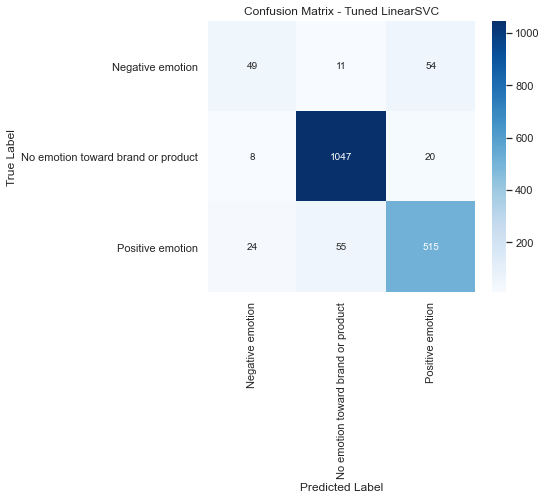

In [57]:
# Generate confusion matrix for the tuned LinearSVC model
cm = confusion_matrix(
    y_test,
    y_pred_3,
    labels=best_model.classes_
)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=best_model.classes_,
    yticklabels=best_model.classes_
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix - Tuned LinearSVC")

plt.show()


### Confusion matrix

The confusion matrix indicates that the model is highly effective at identifying neutral and positive sentiments, with the majority of tweets in these categories being classified correctly.

In contrast, negative sentiment continues to be the most difficult class to predict accurately. A portion of negative tweets is misclassified as either neutral or positive, which may be attributed to similarities in the language and expressions used across sentiment categories. Nevertheless, the optimized LinearSVC model shows noticeable improvement in recognizing negative sentiment compared to previous models, demonstrating enhanced capability in handling minority-class instances

### 7. MODEL INTERPRETATION

#### Feature Importance Analysis
The best model as identified above is a LinearSVC whose features have a linear relationship to the coefficient magnitudes.


In [58]:
# Extract feature names from the preprocessing pipeline
# Get fitted transformers
preprocessor = best_model.named_steps['preprocessor']

# TF-IDF feature names
text_features = preprocessor.named_transformers_['text'].get_feature_names()

# OneHotEncoder feature names
brand_features = preprocessor.named_transformers_['brand'].get_feature_names(
    ['target_brand']
)

# Combine feature names
feature_names = np.concatenate([
    text_features,
    brand_features
])

# Get coefficients
coefs = best_model.named_steps['classifier'].coef_

# Display important features
for i, class_name in enumerate(
    best_model.named_steps['classifier'].classes_
):

    coef_df = pd.DataFrame({
        'feature': feature_names,
        'weight': coefs[i]
    })

    coef_df = coef_df.sort_values(
        by='weight',
        ascending=False
    )

    print(f"\nTop features for {class_name}")

    display(coef_df.head(10))


Top features for Negative emotion


,feature,weight
3692,insane,2.553686
816,boooo,2.454139
3285,hate,2.452278
1633,crashes,2.360727
4310,long,2.170993
4113,launchquot,2.158223
3309,headaches,2.156931
6756,shipments,2.102465
5289,partying,2.080045
6394,ridic,2.019873



Top features for No emotion toward brand or product


,feature,weight
4321,looms,1.335427
57,actual,1.238594
8673,target_brand_other,1.161128
7511,tablets,0.954283
1604,coverage,0.912422
222,amthey,0.903098
5470,plagued,0.901146
8020,ummmmditto,0.855226
7997,tysons,0.853633
3929,joke,0.830975



Top features for Positive emotion


,feature,weight
4375,luckily,1.452306
7756,tipped,1.426039
3179,gtgt,1.422018
6650,seevisit,1.400697
2224,ears,1.399111
6838,simplicity,1.379681
6926,smart,1.332076
3586,imagine,1.323151
7193,status,1.302994
575,bankinnovation,1.300832


#### Feature Selection Interpretation
Feature importance analysis reveals the key words and brand-related factors that drive sentiment predictions. Variables with higher positive weights play a greater role in the model's classification decisions, influencing whether a tweet is labeled as positive, negative, or neutral.

Visualizing Most Important Features

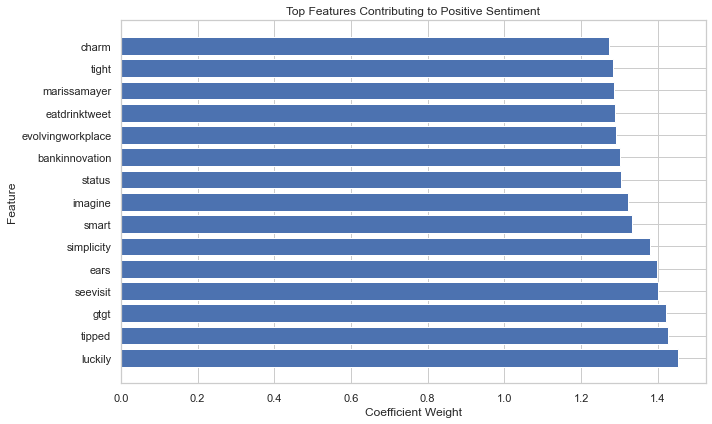

In [59]:
# Visualize the most influential features
# for the positive sentiment class

positive_class = 2

coef_df = pd.DataFrame({
    'feature': feature_names,
    'importance': coefs[positive_class]
})

top_features = (
    coef_df
    .sort_values('importance', ascending=False)
    .head(15)
)

plt.figure(figsize=(10,6))

plt.barh(
    top_features['feature'],
    top_features['importance']
)

plt.title(
    'Top Features Contributing to Positive Sentiment'
)

plt.xlabel('Coefficient Weight')
plt.ylabel('Feature')

plt.tight_layout()
plt.show()

Words features with higher positive weights have a greater influence on the model's predictions, thereby contributing to the categorization of tweets into positive classification thus making the model explain the decision making process.

### 8. LOCAL MODEL EXPLANATION WITH LIME

LIME is useful in explaining the individual predictions whereby it approximates the model locally using simple interpretable model around specific data point. It identifes the words/features that mostly influenced the single prediction hence helping to comprehend the classification of the different sentiments.

In [60]:
! pip install lime

In [61]:
from lime.lime_text import LimeTextExplainer

# Train a text-only Logistic Regression model
# specifically for LIME explanations

lime_model = Pipeline([
    (
        'tfidf',
        TfidfVectorizer(
            max_features=5000,
            stop_words='english'
        )
    ),
    (
        'clf',
        LogisticRegression(
            max_iter=1000
        )
    )
])

lime_model.fit(
    X_train['clean_tweet'],
    y_train
)

# Create LIME explainer

class_names = (
    lime_model.named_steps['clf']
    .classes_
)

explainer = LimeTextExplainer(
    class_names=class_names
)

# Prediction function for LIME

def predict_proba(texts):
    return lime_model.predict_proba(texts)

# Select a test example

i = 10

text_instance = (
    X_test['clean_tweet']
    .iloc[i]
)

# Generate explanation

exp = explainer.explain_instance(
    text_instance,
    predict_proba,
    num_features=10
)

exp.show_in_notebook()

Based on the above, he other probabilities show much less support on the remaining classes i.e. 0.26 towards Positive emotion and 0.03 towards Negative emotion.the model predicted a probability of 0.71 on the tweet as No emotion toward brand or product. This implies that the sentiment expressed is neutral. However, t
The LIME explanation shows words like 'far', contributed to the model classifying the negative tweet as they generally implicate dissatisfaction.  The words 'longest', 'line' contributed to the neutral tweets thus strongly pushing the model toward neutral sentiment.
The neutral comments may depict both disatisfaction and satisfaction hence words leading to such emotions should be analysed to help transform them into positive emotions.

### 9. KEY FINDINGS


- The sentiment analysis shows that most tweets are concentrated in the neutral class. This implies that users of Apple and Google products more often express the brand emotions without expressing a strong emotional tone.

- The minority class is the negative emotions sentiment since it has the least number of tweets. 

- A class imbalance among the three sentiment classes makes the model to learn more on the neutral sentiments due to the high frequency of such tweets. This affects the model performance.

- Text preprocessing significantly improved data quality by removing noise and standardizing tweet content.

- The models, Logistic Regression, and Naive Bayes performed well in their accuracy scores but failed in identifying the minority class. The two models the models are effective at identifying neutral sentiment but struggled more with distinguishing negative classes due to fewer strongly opinionated examples in the dataset.

- LinearSVC performed the best in ensuring a balanced performance across the sentiments.

- Hyperparameter tuning further improved the model's ability to detect negative sentiment while maintaining high overall accuracy.

- Overall, the findings demonstrate that the LinearSVC model is well-suited for sentiment classification tasks involving short social media texts, while also highlighting the impact of class imbalance on predictive performance.

### 10. RECOMMENDATIONS

- I recommend the implementation of the optimized LinearSVC model for continuous automated sentiment tracking.

- More attention should be made on the negative sentiment trends, as they may signal developing customer issues or dissatisfaction.

- Gather more negative tweet samples to strengthen representation of the minority class in the dataset.

- Investigate advanced methods such as SMOTE or transformer-based approaches to enhance model performance further.

- Regularly update and retrain the model using fresh social media data to keep up with evolving language and user sentiment patterns.

### 11. CONCLUSION

This project built and assessed machine learning models to classify the sentiment of Twitter posts related to Apple and Google products. Following thorough data preprocessing, feature extraction, and model evaluation, multiple classification algorithms were compared.

The optimized LinearSVC model performed best overall, achieving strong accuracy and relatively balanced predictions across sentiment classes. These findings show that machine learning can effectively interpret social media sentiment and generate useful insights for brand monitoring and understanding customer feedback.